In [1]:
import scarf

scarf.configure_output(level="ERROR", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

Downloading bucket files: 40169307 / 40169307 complete

Downloading bytes: 40169307 / 40169307 complete

Downloading bucket files: 46151508 / 46151508 complete

Downloading bytes: 46151508 / 46151508 complete

In [2]:
merged_path = "scarf_datasets/kang_dataset_merging.zarr"
scarf.DataStoreMerge(
    datasets=[ds_ctrl, ds_stim],
    zarr_path=merged_path,
    names=["ctrl", "stim"],
    assays=["RNA"],
    prepend_text="orig",
    reset_cell_filter=False,
    source_column="sample_id",
    overwrite=True,
).dump()

ds = scarf.DataStore(merged_path, nthreads=4)

Writing merged assay RNA: 9 / 9 complete

Writing transposed counts: 20 / 20 complete

Computing RNA initialization statistics: 4 / 4 complete

In [3]:
active_cells = ds.cells.to_pandas_dataframe(
    ["sample_id", "orig_cluster_labels"],
    key="I",
)
active_cells.groupby("sample_id")["orig_cluster_labels"].agg(
    cells="count",
    cell_types="nunique",
)

,cells,cell_types
sample_id,,
ctrl,8486,13
stim,10111,13


In [4]:
baseline = ds.pipeline.run(
    filtering=False,
    cell_cycle_scoring=False,
    highly_variable_features={
        "min_cells": 10,
        "top_n": 2000,
        "min_mean": -3,
        "max_mean": 2,
        "max_var": 6,
    },
    pca={"dims": 25},
    neighbors={"k": 21},
    umap={
        "n_epochs": 250,
        "spread": 5,
        "min_dist": 1,
        "parallel": True,
    },
    leiden={1.0: {"label": "integration_clusters"}},
    paris=False,
    doublet_scoring=False,
    markers=False,
)

Computing RNA feature statistics: 20 / 20 complete

Writing data: 2 / 2 complete

Fitting PCA: 2 / 2 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 2 / 2 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Training UMAP: 250 / 250 complete

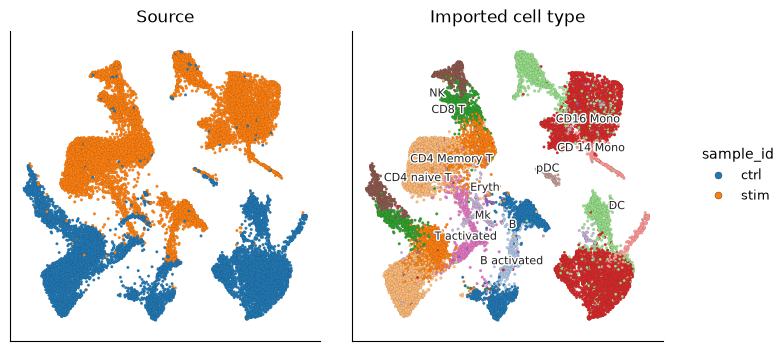

In [5]:
comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=["sample_id", "orig_cluster_labels"],
    n_columns=2,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    comparison.axes.values(),
    ("Source", "Imported cell type"),
    strict=True,
):
    axis.set_title(title)
comparison.show()

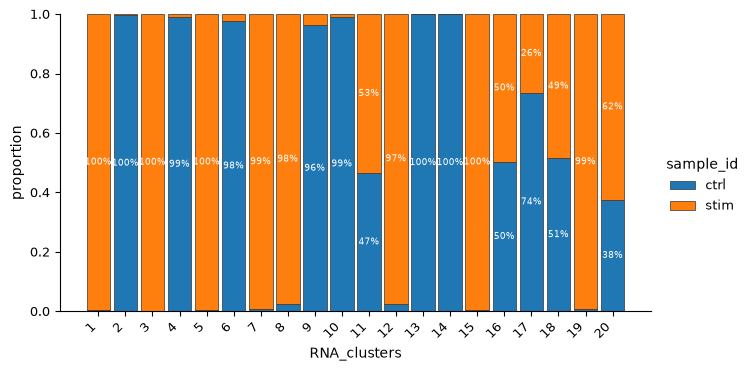

In [6]:
ds.plots.composition(
    category_by="sample_id",
    sample_by="RNA_clusters",
    kind="stacked",
    show_percent_labels=True,
)

In [7]:
uncorrected_ilisi = ds.metric_ilisi(
    batch_colname="sample_id",
    perplexity=7,
)
{"uncorrected iLISI": round(uncorrected_ilisi, 3)}

Computing LISI: 2 / 2 complete

{'uncorrected iLISI': 0.0}